<a href="https://colab.research.google.com/github/Ajinkya718/portfo/blob/main/extras/exercises/04_pytorch_custom_datasets_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. PyTorch Custom Datasets Exercises Template

Welcome to the 04. PyTorch Custom Datasets exercise template.

The best way to practice PyTorch code is to write more PyTorch code.

So read the original notebook and try to complete the exercises by writing code where it's required.

Feel free to reference the original resources whenever you need but should practice writing all of the code yourself.

## Resources

1. These exercises/solutions are based on [notebook 04 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/04_pytorch_custom_datasets/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/vsFMF9wqWx0).
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [99]:
# Check for GPU
!nvidia-smi

Thu May  7 04:34:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             34W /   70W |     233MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [100]:
# Import torch
import torch
from torch import nn

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.10.0+cu128


'cuda'

## 1. Our models are underperforming (not fitting the data well). What are 3 methods for preventing underfitting? Write them down and explain each with a sentence.

To prevent underfitting in ML, which occurs when a model is too simple to capture the underlying data structure, you can increase model complexity, engineer better features, or reduce regularization. These methods help the model learn the nuances and patterns withing the training data, improving in accuracy in both training and test sets.

1. Increase Model Complexity: Use a more complex algorithm. (e.g - changing from linear regression to a decision tree or a neural network) or add more layers/neurons in a neural network, as simpler models with higher biases fail to learn complex trends.
2. Feature engineering/selection: Introduce more relevant, meaningful features or transform existing data to represent complex relationships better, ensuring the model has enough information to learn.
3. Decrease/remove Regularization: Reduce or eliminate techniques like L1/L2 regularization (Lasso/Ridge) that impose penalties on model complexity. Reducing these restrictions allows the model to learn more freely and better fit the data.

## 2. Recreate the data loading functions we built in [sections 1, 2, 3 and 4 of notebook 04](https://www.learnpytorch.io/04_pytorch_custom_datasets/). You should have train and test `DataLoader`'s ready to use.

In [101]:
# 1. Get data
import requests
import zipfile
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"
if image_path.is_dir():
  print(f"{image_path} already exists. Skipping download...")
else:
  image_path.mkdir(parents=True, exist_ok=True)

# Downloading pizza_steak_sushi data
with open(data_path / "pizza_steak_sushi.zip", "wb") as file:
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/data/pizza_steak_sushi.zip")
  print("Downloading pizza_steak_sushi data...")
  file.write(request.content)

# Unzip pizza steak sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
  print("Unzipping pizza_steak_sushi data...")
  zip_ref.extractall(image_path)

data/pizza_steak_sushi already exists. Skipping download...
Unzipping pizza_steak_sushi data...


In [102]:
# 2. Become one with the data
import os
def walk_through_dir(dir_path):
  """Walks through dir_path returning file counts of its contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [103]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.


In [104]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

data/pizza_steak_sushi/train/sushi/2492146.jpg
sushi
Image height: 384
Image width: 512


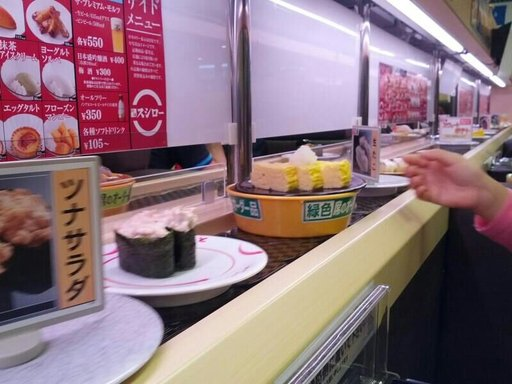

In [105]:
# Visualize an image
import random
from PIL import Image

image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list

random_image_path = random.choice(image_path_list)
print(random_image_path)

image_class = random_image_path.parent.stem
print(image_class)

img = Image.open(random_image_path)
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

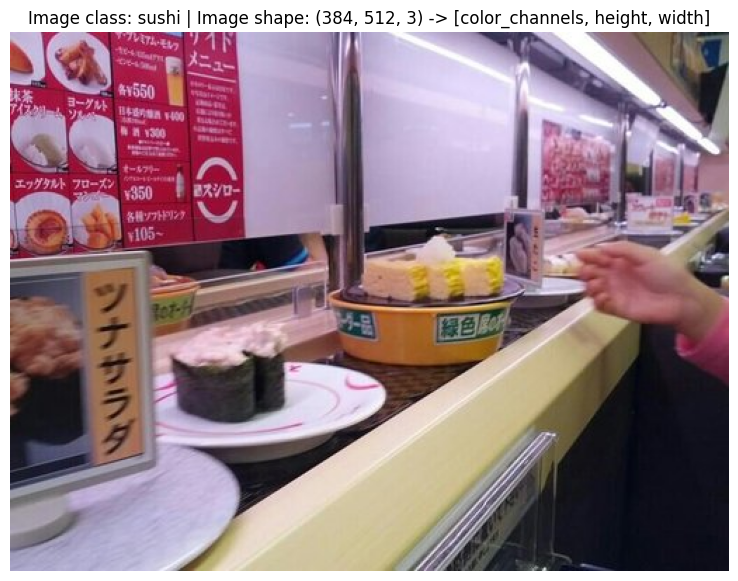

In [106]:
# Do the image visualization with matplotlib
import numpy as np
import matplotlib.pyplot as plt

img_as_array = np.asarray(img)

plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [color_channels, height, width]")
plt.axis(False);

We've got some images in our folders.

Now we need to make them compatible with PyTorch by:
1. Transform the data into tensors.
2. Turn the tensor data into a `torch.utils.data.Dataset` and later a `torch.utils.data.DataLoader`.

In [107]:
# 3.1 Transforming data with torchvision.transforms
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

data_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor()
])
data_transform

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
)

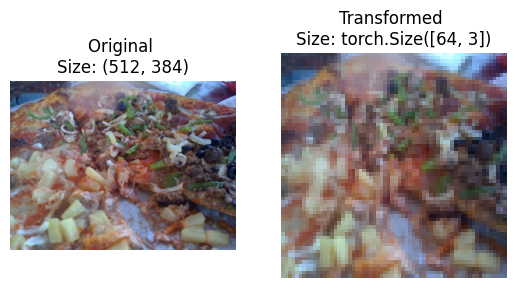

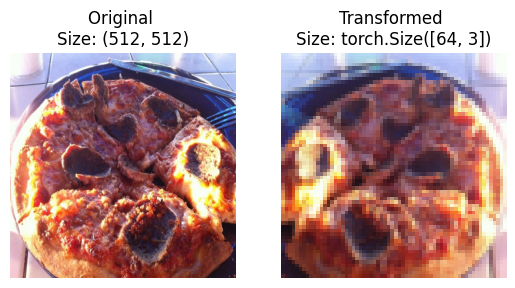

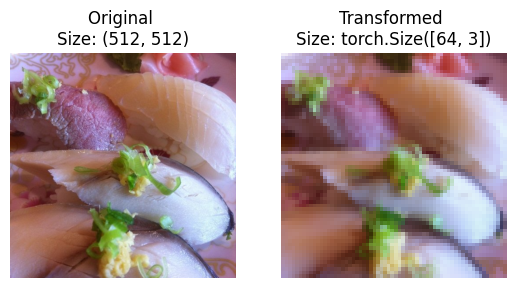

In [108]:
# Write a function to plot transformed images
def plot_transformed_images(image_paths, transform, n=3, seed=42):
  """Plots n transforms of a selected image."""
  random.seed(seed)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(1, 2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original \nSize: {f.size}")
      ax[0].axis(False)

      transformed_image = transform(f).permute(1, 2, 0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed \nSize: {transformed_image.shape[-2:]}")
      ax[1].axis(False)

plot_transformed_images(image_path_list, data_transform, n=3)

### Load image data using `ImageFolder`

In [109]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [110]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [111]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [112]:
# Check the lengths of each dataset
len(train_data), len(test_data)

(225, 75)

In [113]:
# Turn train and test Datasets into DataLoaders
import os
BATCH_SIZE = 32
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=os.cpu_count(),
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=os.cpu_count(),
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7d3190131fa0>,
 <torch.utils.data.dataloader.DataLoader at 0x7d3192017470>)

In [114]:
# How many batches of images are in our data loaders?
len(train_dataloader), len(test_dataloader)

(8, 3)

## 3. Recreate `model_0` we built in section 7 of notebook 04.

In [115]:
class TinyVGG(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(
      nn.Conv2d(in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=0),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=0),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2,
                    stride=2)
    )
    self.conv_block_2 = nn.Sequential(
      nn.Conv2d(in_channels = hidden_units,
               out_channels = hidden_units,
               kernel_size = 3,
               stride = 1,
               padding = 0),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=0),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2,
                    stride=2)
    )
    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features=hidden_units*13*13,
                out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier(x)
    return x

In [116]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

## 4. Create training and testing functions for `model_0`.

In [117]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):

  # Put the model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader and data batches
  for batch, (X, y) in enumerate(dataloader):

    # Send data to target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)

    # 2. Calculate and accumulate loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Calculate and accumualte accuracy metric across all batches
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  # Adjust metrics to get average loss and average accuracy per batch
  train_loss /= len(dataloader)
  train_acc /= len(dataloader)

  return train_loss, train_acc

In [118]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):

  # Put model in eval mode
  model.eval()

  # Setup the test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference context manager
  with torch.inference_mode():
    # Loop through DataLoader batches
    for batch, (X, y) in enumerate(dataloader):
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      test_pred = model(X)

      # 2. Calculuate and accumulate loss
      test_loss += loss_fn(test_pred, y).item()

      # Calculate and accumulate accuracy
      test_pred_class = torch.argmax(torch.softmax(test_pred, dim=1), dim=1)
      test_acc += (test_pred_class == y).sum().item()/len(test_pred)

  # Adjust metrics to get average loss and accuracy per batch
  test_loss /= len(dataloader)
  test_acc /= len(dataloader)

  return test_loss, test_acc

In [119]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

  # Create results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  # Loop through the training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
    # Train step
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer)
    # Test step
    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn)

    # Print out what's happening
    print(f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
    )

    # Update the results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # Return the results dictionary
  return results

## 5. Try training the model you made in exercise 3 for 5, 20 and 50 epochs, what happens to the results?
* Use `torch.optim.Adam()` with a learning rate of 0.001 as the optimizer.

In [120]:
# Train for 5 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(),
                             lr=0.001)
train(model=model_0,
      train_dataloader=train_dataloader,
      test_dataloader=test_dataloader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=5)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1035 | train_acc: 0.2500 | test_loss: 1.0993 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.0759 | train_acc: 0.4258 | test_loss: 1.1302 | test_acc: 0.2604
Epoch: 3 | train_loss: 1.0731 | train_acc: 0.4258 | test_loss: 1.1636 | test_acc: 0.2604
Epoch: 4 | train_loss: 1.1105 | train_acc: 0.3047 | test_loss: 1.1551 | test_acc: 0.2604
Epoch: 5 | train_loss: 1.0860 | train_acc: 0.3672 | test_loss: 1.1539 | test_acc: 0.2500


{'train_loss': [1.1035127639770508,
  1.0758915096521378,
  1.0730566084384918,
  1.1105420589447021,
  1.085963249206543],
 'train_acc': [0.25, 0.42578125, 0.42578125, 0.3046875, 0.3671875],
 'test_loss': [1.0993155241012573,
  1.1302306254704793,
  1.1635594765345256,
  1.155119518438975,
  1.1538804769515991],
 'test_acc': [0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.25]}

In [121]:
# Train for 20 epochs
torch.manual_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(),
                             lr=0.001)
train(model=model_0,
      train_dataloader=train_dataloader,
      test_dataloader=test_dataloader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=20)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0531 | train_acc: 0.5625 | test_loss: 1.0741 | test_acc: 0.3229
Epoch: 2 | train_loss: 1.0091 | train_acc: 0.5117 | test_loss: 1.0898 | test_acc: 0.3428
Epoch: 3 | train_loss: 0.9631 | train_acc: 0.5352 | test_loss: 1.1107 | test_acc: 0.3333
Epoch: 4 | train_loss: 0.9543 | train_acc: 0.5898 | test_loss: 1.1069 | test_acc: 0.2708
Epoch: 5 | train_loss: 0.8899 | train_acc: 0.6016 | test_loss: 1.0694 | test_acc: 0.3002
Epoch: 6 | train_loss: 1.0425 | train_acc: 0.4727 | test_loss: 1.0297 | test_acc: 0.3305
Epoch: 7 | train_loss: 0.8078 | train_acc: 0.6211 | test_loss: 1.0573 | test_acc: 0.4858
Epoch: 8 | train_loss: 0.8381 | train_acc: 0.6641 | test_loss: 1.0074 | test_acc: 0.3305
Epoch: 9 | train_loss: 0.9497 | train_acc: 0.4805 | test_loss: 1.0385 | test_acc: 0.3513
Epoch: 10 | train_loss: 0.8338 | train_acc: 0.6641 | test_loss: 0.9798 | test_acc: 0.5142
Epoch: 11 | train_loss: 0.8019 | train_acc: 0.6641 | test_loss: 0.9842 | test_acc: 0.4233
Epoch: 12 | train_l

{'train_loss': [1.053077608346939,
  1.0091016218066216,
  0.9631187096238136,
  0.954314149916172,
  0.8898720741271973,
  1.0424550920724869,
  0.8077974896878004,
  0.8380681723356247,
  0.9497078955173492,
  0.833808533847332,
  0.8018703386187553,
  0.7688299044966698,
  0.7824247628450394,
  0.7864480689167976,
  1.0382339507341385,
  0.7925501465797424,
  0.8807498812675476,
  0.825017049908638,
  0.7755353637039661,
  0.8791131526231766],
 'train_acc': [0.5625,
  0.51171875,
  0.53515625,
  0.58984375,
  0.6015625,
  0.47265625,
  0.62109375,
  0.6640625,
  0.48046875,
  0.6640625,
  0.6640625,
  0.62890625,
  0.6796875,
  0.63671875,
  0.5859375,
  0.64453125,
  0.6171875,
  0.66015625,
  0.65234375,
  0.53125],
 'test_loss': [1.0740718841552734,
  1.089778979619344,
  1.1107320388158162,
  1.106869101524353,
  1.0694003502527873,
  1.029677430788676,
  1.0572525064150493,
  1.0073628425598145,
  1.0385205149650574,
  0.9798274636268616,
  0.9842194517453512,
  1.0459271073341

In [122]:
# Train for 50 epochs
torch.manual_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(),
                             lr=0.001)
train(model=model_0,
      train_dataloader=train_dataloader,
      test_dataloader=test_dataloader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=50)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.8084 | train_acc: 0.5664 | test_loss: 1.0348 | test_acc: 0.4233
Epoch: 2 | train_loss: 0.8024 | train_acc: 0.6602 | test_loss: 1.0421 | test_acc: 0.4025
Epoch: 3 | train_loss: 0.7250 | train_acc: 0.6836 | test_loss: 1.1008 | test_acc: 0.3930
Epoch: 4 | train_loss: 0.8579 | train_acc: 0.5820 | test_loss: 1.0757 | test_acc: 0.4223
Epoch: 5 | train_loss: 0.7263 | train_acc: 0.7148 | test_loss: 1.0902 | test_acc: 0.4536
Epoch: 6 | train_loss: 0.9398 | train_acc: 0.5664 | test_loss: 1.0717 | test_acc: 0.4233
Epoch: 7 | train_loss: 0.6883 | train_acc: 0.7109 | test_loss: 1.0560 | test_acc: 0.4347
Epoch: 8 | train_loss: 0.7616 | train_acc: 0.7148 | test_loss: 1.0373 | test_acc: 0.3930
Epoch: 9 | train_loss: 0.8443 | train_acc: 0.5898 | test_loss: 1.0613 | test_acc: 0.4233
Epoch: 10 | train_loss: 0.7272 | train_acc: 0.7148 | test_loss: 0.9853 | test_acc: 0.4640
Epoch: 11 | train_loss: 0.7185 | train_acc: 0.7031 | test_loss: 1.0057 | test_acc: 0.4233
Epoch: 12 | train_l

{'train_loss': [0.8083904981613159,
  0.8024322763085365,
  0.7249825149774551,
  0.8578905388712883,
  0.7262936681509018,
  0.9397949054837227,
  0.6883080555126071,
  0.7616429403424263,
  0.8443245962262154,
  0.7271618098020554,
  0.7184565216302872,
  0.6462929490953684,
  0.7057764604687691,
  0.6947251036763191,
  0.8632949665188789,
  0.6746839880943298,
  0.72903111577034,
  0.6900440119206905,
  0.6530164368450642,
  0.9292498230934143,
  0.7242690101265907,
  0.7884741574525833,
  0.6515492433682084,
  0.7390068992972374,
  0.6624053418636322,
  0.6747091859579086,
  0.6989788115024567,
  0.7075396403670311,
  0.7427226528525352,
  0.708142027258873,
  0.6602882370352745,
  0.6425879374146461,
  0.6306184977293015,
  0.9555068463087082,
  0.8083054795861244,
  0.7852533683180809,
  0.8084040507674217,
  0.7730808034539223,
  0.6623099613934755,
  0.7770809456706047,
  0.8335085511207581,
  0.6862906739115715,
  0.6597275100648403,
  0.6435768753290176,
  0.7349254861474037,

It looks like our model is starting to overfit towards the end (performing far better on the training data than on the testing data).

In order to fix this, we'd have to introduce ways of preventing overfitting.

## 6. Double the number of hidden units in your model and train it for 20 epochs, what happens to the results?

In [123]:
# Double the number of hidden units and train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_1 = TinyVGG(input_shape=3,
                  hidden_units=20,
                  output_shape=len(class_names)).to(device)

In [124]:
optimizer = torch.optim.Adam(model_1.parameters(),
                             lr=0.001)

In [125]:
train(model=model_1,
      train_dataloader=train_dataloader,
      test_dataloader=test_dataloader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=20)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1040 | train_acc: 0.2695 | test_loss: 1.1015 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.1004 | train_acc: 0.3047 | test_loss: 1.1001 | test_acc: 0.2396
Epoch: 3 | train_loss: 1.0954 | train_acc: 0.3125 | test_loss: 1.0859 | test_acc: 0.2604
Epoch: 4 | train_loss: 1.1163 | train_acc: 0.3047 | test_loss: 1.0971 | test_acc: 0.2604
Epoch: 5 | train_loss: 1.0847 | train_acc: 0.4570 | test_loss: 1.1160 | test_acc: 0.1979
Epoch: 6 | train_loss: 1.0701 | train_acc: 0.4141 | test_loss: 1.1531 | test_acc: 0.1979
Epoch: 7 | train_loss: 1.0885 | train_acc: 0.2930 | test_loss: 1.1502 | test_acc: 0.2917
Epoch: 8 | train_loss: 1.0649 | train_acc: 0.4297 | test_loss: 1.1161 | test_acc: 0.3021
Epoch: 9 | train_loss: 0.9982 | train_acc: 0.5938 | test_loss: 1.0813 | test_acc: 0.3428
Epoch: 10 | train_loss: 1.0282 | train_acc: 0.4727 | test_loss: 0.9673 | test_acc: 0.6155
Epoch: 11 | train_loss: 0.9367 | train_acc: 0.5547 | test_loss: 0.9197 | test_acc: 0.5634
Epoch: 12 | train_l

{'train_loss': [1.104000300168991,
  1.100424885749817,
  1.0954087674617767,
  1.1162682324647903,
  1.0847439616918564,
  1.0700769573450089,
  1.0885213017463684,
  1.06492081284523,
  0.9982437863945961,
  1.02815992385149,
  0.936735101044178,
  0.8896967321634293,
  0.8083361014723778,
  0.8080808371305466,
  1.1290108561515808,
  0.8003655523061752,
  0.7707504238933325,
  0.8177717179059982,
  0.8028872162103653,
  0.6637316101696342],
 'train_acc': [0.26953125,
  0.3046875,
  0.3125,
  0.3046875,
  0.45703125,
  0.4140625,
  0.29296875,
  0.4296875,
  0.59375,
  0.47265625,
  0.5546875,
  0.5703125,
  0.6796875,
  0.56640625,
  0.5390625,
  0.6796875,
  0.609375,
  0.69921875,
  0.640625,
  0.71875],
 'test_loss': [1.1015084187189739,
  1.100101629892985,
  1.0859404404958088,
  1.0970760186513264,
  1.1159510215123494,
  1.1530580520629883,
  1.1502227783203125,
  1.1161386171976726,
  1.081328292687734,
  0.9673449794451395,
  0.9196609854698181,
  1.0088423887888591,
  1.01

It looks like the model is still overfitting, even when changing the number of hidden units.

To fix this, we'd have to look at ways to prevent overfitting with our model.

## 7. Double the data you're using with your model from step 6 and train it for 20 epochs, what happens to the results?
* **Note:** You can use the [custom data creation notebook](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb) to scale up your Food101 dataset.
* You can also find the [already formatted double data (20% instead of 10% subset) dataset on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip), you will need to write download code like in exercise 2 to get it into this notebook.

In [126]:
# Download 20% data for Pizza/Steak/Sushi from GitHub
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

# Download pizza, steak, sushi data
with open(data_path / "pizza_steak_sushi_20_percent.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
    print("Downloading pizza, steak, sushi 20% data...")
    f.write(request.content)

# Unzip pizza, steak, sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi_20_percent.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi 20% data...")
    zip_ref.extractall(image_path)

data/pizza_steak_sushi_20_percent directory exists.
Unzipping pizza, steak, sushi 20% data...


In [127]:
# See how many images we have
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi_20_percent'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi_20_percent/train'.
There are 0 directories and 154 images in 'data/pizza_steak_sushi_20_percent/train/pizza'.
There are 0 directories and 150 images in 'data/pizza_steak_sushi_20_percent/train/sushi'.
There are 0 directories and 146 images in 'data/pizza_steak_sushi_20_percent/train/steak'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi_20_percent/test'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/pizza'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/sushi'.
There are 0 directories and 58 images in 'data/pizza_steak_sushi_20_percent/test/steak'.


Excellent, we now have double the training and testing images...

In [128]:
# Create the train and test paths
train_data_20_percent_path = image_path / "train"
test_data_20_percent_path = image_path / "test"

train_data_20_percent_path, test_data_20_percent_path

(PosixPath('data/pizza_steak_sushi_20_percent/train'),
 PosixPath('data/pizza_steak_sushi_20_percent/test'))

In [129]:
# Turn the 20 percent datapaths into Datasets and DataLoaders
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

simple_transform = transforms.Compose([
  transforms.RandomHorizontalFlip(p=1),
  transforms.Resize((64, 64)),
  transforms.ToTensor()
])

# Create datasets
train_dataset = ImageFolder(root=train_data_20_percent_path,
                            transform=simple_transform,
                            target_transform=None)

test_dataset = ImageFolder(root=test_data_20_percent_path,
                           transform=simple_transform)
# Create dataloaders
train_dataloader_20_percent = DataLoader(dataset=train_dataset,
                                        batch_size=BATCH_SIZE,
                                        num_workers=os.cpu_count(),
                                        shuffle=True)

test_dataloader_20_percent = DataLoader(dataset=test_dataset,
                                        batch_size=BATCH_SIZE,
                                        num_workers=os.cpu_count(),
                                        shuffle=False)

In [130]:
# Train a model with increased amount of data
torch.manual_seed(42)
torch.cuda.manual_seed(42)
train(model = model_1,
      train_dataloader=train_dataloader_20_percent,
      test_dataloader=test_dataloader_20_percent,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs = 10)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.8352 | train_acc: 0.6104 | test_loss: 0.8831 | test_acc: 0.5716
Epoch: 2 | train_loss: 0.8387 | train_acc: 0.6396 | test_loss: 0.8731 | test_acc: 0.6074
Epoch: 3 | train_loss: 0.7989 | train_acc: 0.6542 | test_loss: 0.8675 | test_acc: 0.6307
Epoch: 4 | train_loss: 0.7116 | train_acc: 0.7104 | test_loss: 0.8780 | test_acc: 0.6074
Epoch: 5 | train_loss: 0.7197 | train_acc: 0.6687 | test_loss: 0.9113 | test_acc: 0.5807
Epoch: 6 | train_loss: 0.7195 | train_acc: 0.6625 | test_loss: 0.8514 | test_acc: 0.6193
Epoch: 7 | train_loss: 0.6265 | train_acc: 0.7396 | test_loss: 0.9116 | test_acc: 0.6136
Epoch: 8 | train_loss: 0.6253 | train_acc: 0.7396 | test_loss: 0.8710 | test_acc: 0.6000
Epoch: 9 | train_loss: 0.5672 | train_acc: 0.7583 | test_loss: 0.9495 | test_acc: 0.5687
Epoch: 10 | train_loss: 0.5811 | train_acc: 0.7063 | test_loss: 0.9106 | test_acc: 0.5818


{'train_loss': [0.8351837356885274,
  0.8386821190516154,
  0.7989362557729085,
  0.7116026262442271,
  0.7197331706682841,
  0.7194795966148376,
  0.6265040338039398,
  0.6253401150306066,
  0.5671881973743439,
  0.5811471561590831],
 'train_acc': [0.6104166666666667,
  0.6395833333333333,
  0.6541666666666667,
  0.7104166666666667,
  0.66875,
  0.6625,
  0.7395833333333334,
  0.7395833333333334,
  0.7583333333333333,
  0.70625],
 'test_loss': [0.8831475973129272,
  0.8731166124343872,
  0.8675284147262573,
  0.8779865980148316,
  0.9113153934478759,
  0.8513554275035858,
  0.9115718543529511,
  0.870960795879364,
  0.9494751870632172,
  0.9106326639652252],
 'test_acc': [0.571590909090909,
  0.6073863636363637,
  0.6306818181818181,
  0.6073863636363637,
  0.5806818181818182,
  0.6193181818181819,
  0.6136363636363636,
  0.6,
  0.56875,
  0.5818181818181818]}

## 8. Make a prediction on your own custom image of pizza/steak/sushi (you could even download one from the internet) with your trained model from exercise 7 and share your prediction.
* Does the model you trained in exercise 7 get it right?
* If not, what do you think you could do to improve it?

In [ ]:
# Uploading our downloaded image
from google.colab import files
uploaded = files.upload()

In [ ]:
# Opening our image
from PIL import Image
img = Image.open("pizza_steak.png").convert("RGB")
img.show()

In [ ]:
# Transforming our image into a tensor and it's appropriate size
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])
img_tensor = transform(img)
img_tensor.shape

In [ ]:
# Adding batch dimension
img_tensor = img_tensor.unsqueeze(0)
img_tensor.shape

In [ ]:
# Prediction
model_1.eval()
with torch.inference_mode():
  outputs = model_1(img_tensor.to(device))

predicted_class = outputs.argmax(dim=1).item()
prediction = class_names[predicted_class]
print(prediction)

### Results and reflection
The model predicted 'steak' but the image was of 'pizza'. So, the model got it wrong.

Why it might have failed?
* The model is tiny (TinyVGG with only 20 hidden units) and trained on a small dataset.
* Only 20% of the Food101 dataset -> limited number of training images.
* No data augmentation was used, so the model hasn't seen much variety.

How to improve it:
* Data augmentation (random flips, color jitters, rotations) to increase variety.
* Train for more epochs (currently 10 for exercise)
* Use a pretrained model (transfer learning with ResNet, EfficientNet, etc)
* Add regularization (dropout, batch normalization) to reduce overfitting.
* Increase dataset size further (40% of Food101).